In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ephys.src.utils.utils_IO import fetch_good_units, fetch_session_events
from ephys.src.utils.utils_analysis import (
    compute_population_peth,
    compute_unit_selectivity,
    classify_peak_count,
)

%matplotlib widget

/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-03-06 14:45:09,326][INFO]: DataJoint 0.14.9 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


In [2]:
subject = "GRB058"
session = "20260224_152424"

st_per_unit = fetch_good_units(subject, session)
align_ev = fetch_session_events(subject, session)

unit_ids = list(st_per_unit.keys())
print(
    f"Loaded {len(unit_ids)} units, {len(align_ev['first_stim_ev'])} first-stim events"
)

Loaded 144 units, 219 first-stim events


In [3]:
# Compute population PETH aligned to first stimulus onset
peth, bin_edges, bin_centers = compute_population_peth(
    spike_times_per_unit=list(st_per_unit.values()),
    alignment_times=align_ev["first_stim_ev"],
    pre_seconds=0.1,
    post_seconds=0.15,
    binwidth_ms=10,
    t_rise=0.001,
    t_decay=0.025,
)
print(f"PETH shape: {peth.shape}  (units, trials, timebins)")

PETH shape: (144, 219, 23)  (units, trials, timebins)


In [4]:
# Baseline vs response selectivity test
results_df, masks = compute_unit_selectivity(
    peth,
    bin_edges,
    unit_ids=unit_ids,
    base_window=(-0.04, 0.0),
    resp_window=(0.06, 0.10),
    test="wilcoxon",
    alpha=0.05,
)

n_units = peth.shape[0]
print(
    f"Selective: {masks['selective'].sum()}/{n_units} "
    f"({masks['excited'].sum()} excited, {masks['suppressed'].sum()} suppressed)"
)
results_df.head(10)

Selective: 91/144 (39 excited, 52 suppressed)


,unit,mean_base,mean_resp,delta,cohen_d,si,p,q,excited,suppressed,selective
0,0,2.545514,3.036473,0.490960,0.057567,0.087954,6.740299e-01,7.409183e-01,False,False,False
1,1,6.711732,14.687743,7.976011,0.418723,0.372720,1.294787e-08,6.214978e-08,True,False,True
2,15,5.396364,1.119435,-4.276930,-0.404880,-0.656394,1.242321e-08,6.168764e-08,False,True,True
3,14,12.013541,4.943667,-7.069874,-0.354693,-0.416924,8.666199e-07,3.199827e-06,False,True,True
4,12,4.290453,7.959229,3.668776,0.289828,0.299500,1.259551e-05,3.778652e-05,True,False,True
5,346,2.627533,39.771950,37.144417,1.503596,0.876058,3.422762e-35,4.928777e-33,True,False,True
6,154,20.943935,9.318382,-11.625553,-0.692235,-0.384159,2.791046e-18,3.653733e-17,False,True,True
7,8,0.591277,0.233833,-0.357443,-0.101407,-0.433207,1.912673e-01,2.459151e-01,False,False,False
8,148,0.569233,0.225335,-0.343898,-0.121062,-0.432811,1.002696e-01,1.401827e-01,False,False,False
9,343,0.295016,0.048917,-0.246098,-0.117512,-0.715541,7.473550e-02,1.076191e-01,False,False,False


In [5]:
# Classify excited units by number of PSTH peaks
# (suppressed units have sub-baseline responses — peak detection doesn't apply)
exc_idx = np.where(masks["excited"])[0]
exc_peth = peth[exc_idx]
exc_ids = [unit_ids[i] for i in exc_idx]

peaks_df = classify_peak_count(
    exc_peth,
    bin_centers,
    unit_ids=exc_ids,
    search_window=(0.0, 0.15),
    baseline_window=(-0.04, 0.0),
    min_prominence_frac=0.25,
    min_distance_ms=20.0,
    binwidth_ms=10.0,
)

# Merge peak info into results_df
results_df = results_df.merge(
    peaks_df[["unit", "n_peaks", "peak_times"]], on="unit", how="left"
)
results_df["n_peaks"] = results_df["n_peaks"].fillna(0).astype(int)

print(f"Peak count distribution ({len(exc_ids)} excited units):")
print(peaks_df["n_peaks"].value_counts().sort_index().to_string())
print("\nSample rows:")
peaks_df.head(10)

Peak count distribution (39 excited units):
n_peaks
1    35
2     4

Sample rows:


,unit,n_peaks,peak_times,peak_heights
0,1,1,[0.07500000000000001],[15.931312639512651]
1,12,1,[0.065],[10.394030647796926]
2,346,1,[0.065],[45.77021555326793]
3,158,1,[0.125],[18.19318427540545]
4,350,1,[0.055],[69.25552478450967]
5,349,1,[0.045],[8.723561789613868]
6,353,1,[0.065],[2.794777151008253]
7,162,1,[0.055],[19.6498295677078]
8,359,2,"[0.055, 0.095]","[78.57491875877957, 77.46549547669775]"
9,169,1,[0.07500000000000001],[27.671467293557793]


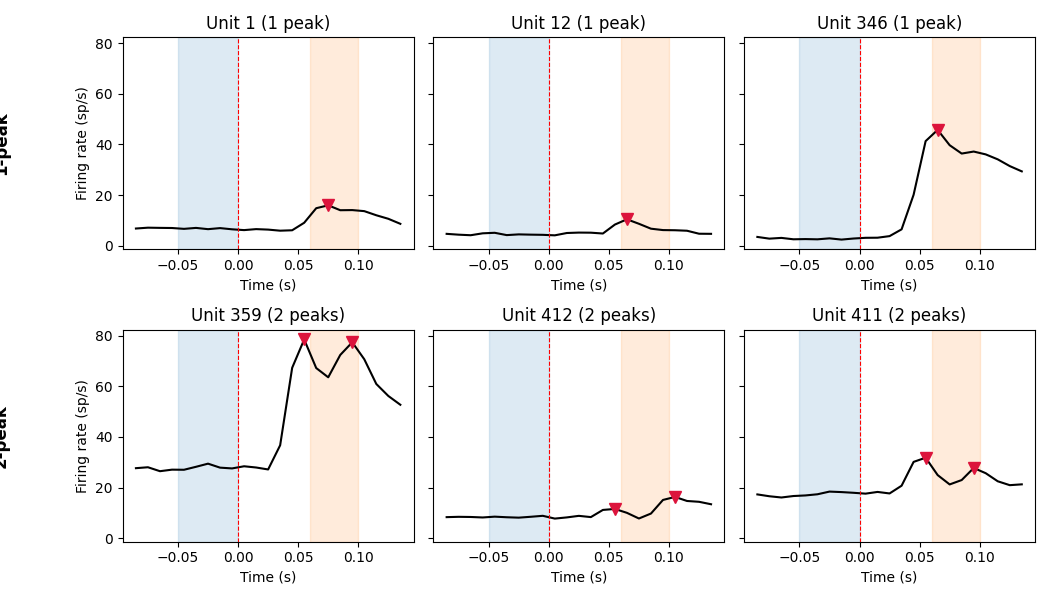

In [10]:
# Example PSTHs grouped by peak count, with detected peaks marked
n_examples = 3  # examples per group
peak_groups = sorted(peaks_df["n_peaks"].unique())
peak_groups = [g for g in peak_groups if g > 0]  # skip 0-peak units

fig, axes = plt.subplots(
    len(peak_groups),
    n_examples,
    figsize=(3.5 * n_examples, 3 * len(peak_groups)),
    sharey=True,
    squeeze=False,
)

for row_i, npk in enumerate(peak_groups):
    group = peaks_df[peaks_df["n_peaks"] == npk].head(n_examples)
    for col_j, (_, prow) in enumerate(group.iterrows()):
        ax = axes[row_i, col_j]
        uid = int(prow["unit"])
        pos = exc_ids.index(uid)
        mean_psth = exc_peth[pos].mean(axis=0)

        ax.plot(bin_centers, mean_psth, color="black", linewidth=1.5)
        ax.axvspan(-0.05, 0.0, color="tab:blue", alpha=0.15)
        ax.axvspan(0.06, 0.10, color="tab:orange", alpha=0.15)
        ax.axvline(0, color="red", linestyle="--", linewidth=0.8)

        # Mark detected peaks
        for pt, ph in zip(prow["peak_times"], prow["peak_heights"]):
            ax.plot(pt, ph, "v", color="crimson", markersize=8, zorder=5)

        ax.set(
            xlabel="Time (s)", title=f"Unit {uid} ({npk} peak{'s' if npk > 1 else ''})"
        )
    axes[row_i, 0].set_ylabel("Firing rate (sp/s)")

    # blank out unused columns
    for col_j in range(len(group), n_examples):
        axes[row_i, col_j].set_visible(False)

# Row labels
for row_i, npk in enumerate(peak_groups):
    axes[row_i, 0].annotate(
        f"{npk}-peak",
        xy=(0, 0.5),
        xytext=(-0.45, 0.5),
        xycoords="axes fraction",
        textcoords="axes fraction",
        fontsize=12,
        fontweight="bold",
        va="center",
        rotation=90,
    )
plt.tight_layout()

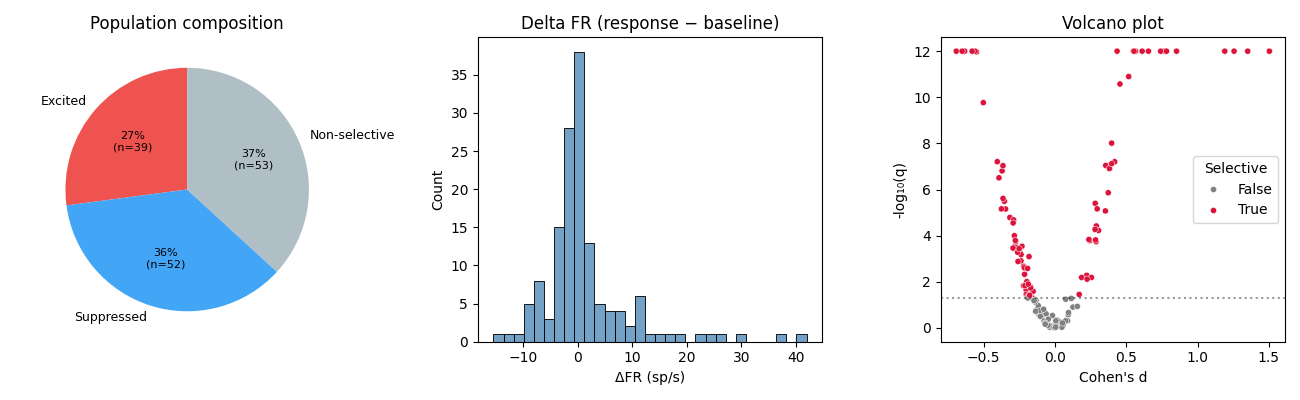

In [9]:
# Summary: pie chart, delta FR histogram, volcano plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# --- Pie chart: population composition ---
pie_labels = ["Excited", "Suppressed", "Non-selective"]
pie_counts = [
    int(masks["excited"].sum()),
    int(masks["suppressed"].sum()),
    n_units - int(masks["selective"].sum()),
]
pie_colors = ["#ef5350", "#42a5f5", "#b0bec5"]
wedges, texts, autotexts = axes[0].pie(
    pie_counts,
    labels=pie_labels,
    colors=pie_colors,
    autopct=lambda p: f"{p:.0f}%\n(n={int(round(p * n_units / 100))})",
    startangle=90,
    textprops={"fontsize": 9},
)
for at in autotexts:
    at.set_fontsize(8)
axes[0].set_title("Population composition")

# --- Delta FR histogram ---
sns.histplot(data=results_df, x="delta", bins=31, ax=axes[1], color="steelblue")
axes[1].set(title="Delta FR (response − baseline)", xlabel="ΔFR (sp/s)", ylabel="Count")

# --- Volcano plot ---
sns.scatterplot(
    data=results_df,
    x="cohen_d",
    y=-np.log10(np.clip(results_df["q"], 1e-12, 1.0)),
    hue="selective",
    palette={True: "crimson", False: "gray"},
    ax=axes[2],
    s=20,
)
axes[2].axhline(-np.log10(0.05), color="k", linestyle=":", alpha=0.4)
axes[2].set(title="Volcano plot", xlabel="Cohen's d", ylabel="-log₁₀(q)")
axes[2].legend(title="Selective", loc="best")
plt.tight_layout()

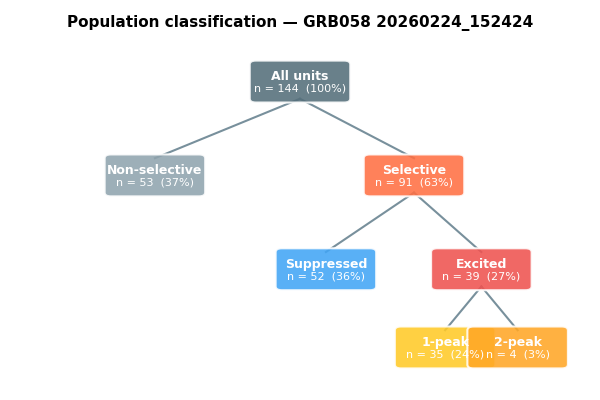

In [8]:
# Population classification tree
from matplotlib.patches import FancyBboxPatch

# Gather counts
n_total = n_units
n_sel = int(masks["selective"].sum())
n_ns = n_total - n_sel
n_exc = int(masks["excited"].sum())
n_sup = int(masks["suppressed"].sum())
pk_counts = peaks_df["n_peaks"].value_counts().sort_index()

# Tree layout: (label, count, x, y, parent_xy)
nodes = [
    ("All units", n_total, 0.50, 0.92, None),
    ("Non-selective", n_ns, 0.22, 0.62, (0.50, 0.92)),
    ("Selective", n_sel, 0.72, 0.62, (0.50, 0.92)),
    ("Suppressed", n_sup, 0.55, 0.32, (0.72, 0.62)),
    ("Excited", n_exc, 0.85, 0.32, (0.72, 0.62)),
]

# Excited sub-groups by peak count
pk_vals = sorted(pk_counts.index)
n_pk = len(pk_vals)
if n_pk > 0:
    x_start = 0.85 - 0.14 * (n_pk - 1) / 2
    for i, npk in enumerate(pk_vals):
        nodes.append(
            (f"{npk}-peak", int(pk_counts[npk]), x_start + i * 0.14, 0.07, (0.85, 0.32))
        )

# Category colors
cat_colors = {
    "All units": "#546e7a",
    "Non-selective": "#90a4ae",
    "Selective": "#ff7043",
    "Suppressed": "#42a5f5",
    "Excited": "#ef5350",
}
for npk in pk_vals:
    cat_colors[f"{npk}-peak"] = (
        "#ffca28" if npk == 1 else "#ffa726" if npk == 2 else "#ff7043"
    )

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.axis("off")

box_w, box_h = 0.17, 0.11

for label, count, x, y, parent in nodes:
    pct = 100 * count / n_total
    color = cat_colors.get(label, "#90a4ae")

    # Connector line
    if parent is not None:
        px, py = parent
        ax.plot(
            [px, x],
            [py - box_h / 2, y + box_h / 2],
            color="#78909c",
            linewidth=1.5,
            zorder=0,
        )

    # Box
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.012",
        facecolor=color,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.88,
        zorder=1,
    )
    ax.add_patch(rect)

    # Label + count
    ax.text(
        x,
        y + 0.015,
        label,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
        zorder=2,
    )
    ax.text(
        x,
        y - 0.023,
        f"n = {count}  ({pct:.0f}%)",
        ha="center",
        va="center",
        fontsize=8,
        color="white",
        zorder=2,
    )

ax.set_title(
    f"Population classification — {subject} {session}",
    fontsize=11,
    fontweight="bold",
    pad=10,
)
plt.tight_layout()